Pre processing dei dati


In [2]:
import torch
import numpy as np
np.random.seed(1122)
torch.random.manual_seed(1122)
print(torch.cuda.is_available())

True


In [3]:
path_dataset = "../dataset/food11"
path_modelli = "../modelli"
path_logs = "../logs_food11"
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [18]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224),      
    transforms.RandomHorizontalFlip(),    
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), 
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

transform_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])


# Creiamo i dataset per training, evaluation e validation
train_dataset = datasets.ImageFolder(
    root=os.path.join(path_dataset, "training"),
    transform=transform_train
)

eval_dataset = datasets.ImageFolder(
    root=os.path.join(path_dataset, "evaluation"),
    transform=transform_train
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(path_dataset, "validation"),
    transform=transform_test
)

class_names = train_dataset.classes
print("Classi trovate:",class_names )

# Creazione dei data loader
train_loader = DataLoader(train_dataset, batch_size= 32, shuffle=True,num_workers=4,
    pin_memory=True)
eval_loader = DataLoader(eval_dataset, batch_size= 32, shuffle=False,num_workers=1,
    pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size= 32, shuffle=False,num_workers=1,
    pin_memory=True)

"""
# Stampare immagini e label
for images, labels in train_loader:
    print("Shape immagini:", images.shape)      # [batch_size, channels, height, width]
    print("Label batch:", labels)
    break
"""
# train + eval
combined_dataset = ConcatDataset([train_dataset, eval_dataset])
combined_loader = DataLoader(combined_dataset, batch_size=32, shuffle=True)

# Stampare immagini e label
for images, labels in combined_loader:
    print("Shape immagini:", images.shape)      # [batch_size, channels, height, width]
    print("Label batch:", labels)
    break

Classi trovate: ['Bread', 'Dairy product', 'Dessert', 'Egg', 'Fried food', 'Meat', 'Noodles-Pasta', 'Rice', 'Seafood', 'Soup', 'Vegetable-Fruit']
Shape immagini: torch.Size([32, 3, 224, 224])
Label batch: tensor([ 3,  3,  0,  2, 10,  0,  9,  3,  1,  1,  4,  9,  5,  0,  3,  4,  2,  6,
         0,  3,  5,  2, 10,  2,  4,  5,  3,  5,  0,  5,  3,  4])


In [5]:
from collections import Counter

def count_images_per_class(dataset, dataset_name):
    counter = Counter(dataset.targets)
    print(f"Distribuzione nel dataset {dataset_name}:")
    for class_idx, num_images in sorted(counter.items()):
        class_name = dataset.classes[class_idx]
        print(f" - Classe '{class_name}': {num_images} immagini")
    print()

# Calcola distribuzioni sui tre dataset
count_images_per_class(train_dataset, "Training")
count_images_per_class(eval_dataset, "Evaluation")
count_images_per_class(val_dataset, "Validation")

Distribuzione nel dataset Training:
 - Classe 'Bread': 994 immagini
 - Classe 'Dairy product': 429 immagini
 - Classe 'Dessert': 1500 immagini
 - Classe 'Egg': 986 immagini
 - Classe 'Fried food': 848 immagini
 - Classe 'Meat': 1325 immagini
 - Classe 'Noodles-Pasta': 440 immagini
 - Classe 'Rice': 280 immagini
 - Classe 'Seafood': 855 immagini
 - Classe 'Soup': 1500 immagini
 - Classe 'Vegetable-Fruit': 709 immagini

Distribuzione nel dataset Evaluation:
 - Classe 'Bread': 368 immagini
 - Classe 'Dairy product': 148 immagini
 - Classe 'Dessert': 500 immagini
 - Classe 'Egg': 335 immagini
 - Classe 'Fried food': 287 immagini
 - Classe 'Meat': 432 immagini
 - Classe 'Noodles-Pasta': 147 immagini
 - Classe 'Rice': 96 immagini
 - Classe 'Seafood': 303 immagini
 - Classe 'Soup': 500 immagini
 - Classe 'Vegetable-Fruit': 231 immagini

Distribuzione nel dataset Validation:
 - Classe 'Bread': 362 immagini
 - Classe 'Dairy product': 144 immagini
 - Classe 'Dessert': 500 immagini
 - Classe 'Egg

In [ ]:
# Salvataggio in csv (es. training)
"""
import csv

csv_path = path_dataset + "train_dataset.csv"

# Le righe hanno la struttura: [path_immagine, label, nome_classe]
with open(csv_path, mode='w', newline='') as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow(["image_path", "label", "class_name"])  # intestazione

    for path, label in train_dataset.samples:
        class_name = train_dataset.classes[label]
        writer.writerow([path, label, class_name])

print(f"CSV salvato in {csv_path}")
"""

Procedure di train, test e valutazione


In [6]:
class AverageValueMeter():
  def __init__(self):
    self.reset()

  def reset(self):
    self.sum = 0
    self.num = 0

  def add(self,value,num):
    self.sum += value*num
    self.num += num

  def value(self):
    try:
      return self.sum/self.num
    except:
      return None

In [19]:
# definiamo la procedura di training vista nel laboratorio precedente
from torch.optim import SGD
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import accuracy_score
from os.path import join
import torch.nn as nn


def train_classifier(model, train_loader, val_loader, exp_name = 'experiment', lr = 0.01, epochs = 10, momentum = 0.99, logdir = 'logs'):
  criterion = nn.CrossEntropyLoss() # funzione di loss
  optimizer = SGD(model.parameters(), lr, momentum = momentum, weight_decay = 0.0001) # funzione di learning

  loss_meter = AverageValueMeter()
  acc_meter = AverageValueMeter()

  # writer
  writer = SummaryWriter(join(path_logs,exp_name))

  # device
  device = 'cuda' if torch.cuda.is_available() else 'cpu'
  model.to(device)

  # definiamo un dizionario contenente i loader di training e test
  loader = {
      'train': train_loader,
      'val': val_loader
  }

  # inizializziamo il global step
  global_step = 0
  for e in range(epochs):
    print(f"Epoch: {e+1} of {epochs}")
    # iteriamo tra due modalità: train e test
    for mode in ['train','val']:
      loss_meter.reset()
      acc_meter.reset()
      model.train() if mode == 'train' else model.eval()
      with torch.set_grad_enabled(mode == 'train'): # abilitiamo i gradienti in training
        for i, batch in enumerate(loader[mode]):
          x = batch[0].to(device) #portiamoli sul device corretto
          y = batch[1].to(device)
          output = model(x)

          # aggiorniamo il global_step
          # conterrà il numero di campioni visti durante il training
          n = x.shape[0]
          global_step += n
          l = criterion(output,y)

          if mode == 'train':
            l.backward()
            optimizer.step()
            optimizer.zero_grad()

          acc = accuracy_score(y.to('cpu'),output.to('cpu').max(1)[1])
          loss_meter.add(l.item(),n)
          acc_meter.add(acc,n)

          # loggiamo i risultati iterazione per iterazione solo durante il training
          if mode == 'train':
            writer.add_scalar('loss/train', loss_meter.value(), global_step = global_step)
            writer.add_scalar('accuracy/train', acc_meter.value(), global_step = global_step)

      # una volta finita l'epoca (sia nel caso di training che test, loggiamo le stime finali)
      writer.add_scalar('loss/'+mode, loss_meter.value(), global_step = global_step)
      writer.add_scalar('accuracy/'+mode, acc_meter.value(), global_step = global_step)

      # conserviamo i pesi del modello alla fine di ogni epoca
      torch.save(model.state_dict(),path_modelli + '/%s-%d.pth' % (exp_name,e+1))
  #torch.save(model.state_dict(), path_modelli + f"{exp_name}-{e+1}.pth")

  return model

In [8]:
# definiamo la consueta funzione per ottenere probabilità di test predette dal modello
def test_classifier(model, loader):
  device = "cuda" if torch.cuda.is_available() else "cpu"
  model.to(device)
  predictions, labels = [],[]
  for batch in loader:
    x = batch[0].to(device)
    y = batch[1].to(device)
    output = model(x)
    preds = output.to("cpu").max(1)[1].numpy() # le funzioni numpy girano solo su cpu
    labs = y.to("cpu").numpy()
    predictions.extend(list(preds))
    labels.extend(list(labs))
  return np.array(predictions), np.array(labels)

In [9]:
# stampa della matrice di confusione
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm,class_names):
    plt.figure(figsize=(12,8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.colorbar()

    n_classes = cm.shape[0]
    if class_names is not None:
        ticks = np.arange(n_classes)
        plt.xticks(ticks, class_names, rotation=45, ha='right')
        plt.yticks(ticks, class_names)
    else:
        plt.xlabel('Predicted label')
        plt.ylabel('True label')

    plt.tight_layout()
    plt.show()


In [ ]:
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)

def evaluate_classifier(y_pred, y_true, class_names=None):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    print("=== Classification Report ===")
    print(report)
    plot_confusion_matrix(cm_norm,class_names)
    return report,cm


Squeezenet



In [11]:
# Funzione che adatta il modello squeezenet al mio specifico task

from torch import nn
from torchvision.models import squeezenet1_0
from torchvision.models import SqueezeNet1_0_Weights

def get_squeezenet_model(num_class = 100):
  model = squeezenet1_0(weights = SqueezeNet1_0_Weights)
  num_class = 11
  model.classifier[1] = nn.Conv2d(512,num_class,kernel_size = (1,1), stride = (1,1))
  model.num_classes = num_class
  return model

squeezenet = get_squeezenet_model()

c:\Users\giova\Documents\Università\Machine learning\machine_learning\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_0_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [12]:
# Funzione che congela i layer del blocco feature e mantiene solo il blocco classifier

def freeze_features(model):

    for param in model.parameters():
        param.requires_grad = False
    
    for param in model.classifier.parameters():
        param.requires_grad = True

    return model

In [13]:
# Funzione che sblocca tutti i layer -> allenare tutto il modello

def unfreeze_all_layers(model):
    
    for param in model.parameters():
        param.requires_grad = True
    
    return model

In [14]:
# Funzione per stampare quali layer sono bloccati e quali sono allenabili 

def print_trainable_layers(model):
    
    for name, param in model.named_parameters():
        status = "Trainable" if param.requires_grad else "Frozen"
        print(f"{name}: {status}")


In [15]:
# Funzione per allenare squeezenet con le feature congelate

def train_with_frozen_features(model, train_loader, val_loader, exp_name, epochs = 30, lr = 0.001):
    model = freeze_features(model)
    # print_trainable_layers(model)
    model = train_classifier(model, train_loader, val_loader, exp_name= exp_name, epochs= epochs, lr= lr, logdir = path_logs)
    return model


In [16]:
# Funzione per allenare squeezenet con tutti i layer scongelati

def train_all_layers(model, train_loader, val_loader, exp_name, epochs = 30, lr = 0.001):
    model = unfreeze_all_layers(model)
    # print_trainable_layers(model)
    model = train_classifier(model, train_loader, val_loader, exp_name= exp_name, epochs= epochs, lr= lr, logdir = path_logs)
    return model

Training e test su squeezenet con layer di estrazione delle features congelati

Epoch: 1 of 1
=== Classification Report ===
                 precision    recall  f1-score   support

          Bread       0.53      0.75      0.62       362
  Dairy product       0.44      0.74      0.55       144
        Dessert       0.75      0.37      0.49       500
            Egg       0.64      0.58      0.61       327
     Fried food       0.63      0.70      0.66       326
           Meat       0.75      0.72      0.73       449
  Noodles-Pasta       0.69      0.97      0.81       147
           Rice       0.00      0.00      0.00        96
        Seafood       0.75      0.73      0.74       347
           Soup       0.79      0.88      0.83       500
Vegetable-Fruit       0.76      0.79      0.78       232

       accuracy                           0.68      3430
      macro avg       0.61      0.66      0.62      3430
   weighted avg       0.68      0.68      0.66      3430



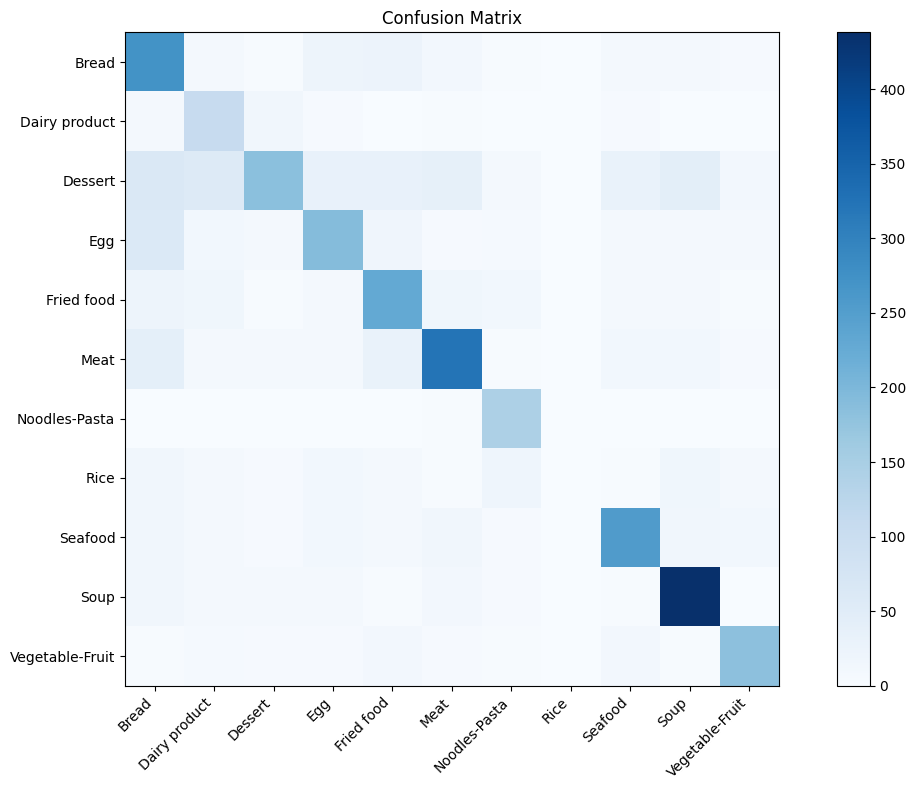

('                 precision    recall  f1-score   support\n\n          Bread       0.53      0.75      0.62       362\n  Dairy product       0.44      0.74      0.55       144\n        Dessert       0.75      0.37      0.49       500\n            Egg       0.64      0.58      0.61       327\n     Fried food       0.63      0.70      0.66       326\n           Meat       0.75      0.72      0.73       449\n  Noodles-Pasta       0.69      0.97      0.81       147\n           Rice       0.00      0.00      0.00        96\n        Seafood       0.75      0.73      0.74       347\n           Soup       0.79      0.88      0.83       500\nVegetable-Fruit       0.76      0.79      0.78       232\n\n       accuracy                           0.68      3430\n      macro avg       0.61      0.66      0.62      3430\n   weighted avg       0.68      0.68      0.66      3430\n',
 array([[271,  10,   2,  21,  24,  11,   3,   0,   7,   8,   5],
        [  8, 107,  15,   5,   0,   2,   1,   0,   4,   

In [ ]:
 # training di squeezenet con i layer di estrazione delle feature congelati
squeezenet_with_frozen_features = train_with_frozen_features(squeezenet, combined_loader, eval_loader, exp_name = "squeezenet_frozen_features_lr=0.001", epochs = 30, lr=0.001)

# test e valutazione sul validation loader
y_pred, y_true = test_classifier(squeezenet_with_frozen_features, val_loader)
evaluate_classifier(y_pred, y_true, class_names)

Training e testing su squeezenet con tutti i layer allenabili


In [ ]:
"""


# training di squeezenet con tutti i layer sbloccati

squeezenet_all_layers = train_all_layers(squeezenet, combined_loader, eval_loader, exp_name = "squeezenet_all_layers_lr=0.001", epochs = 30, lr=0.001)

# test e valutazione sul validation loader
y_pred, y_true = test_classifier(squeezenet_all_layers, val_loader)
evaluate_classifier(y_pred, y_true, class_names)

"""

In [ ]:
"""
y_pred_squeezenet_food11, y_true_food11 = test_classifier(model, eval_loader)
print(accuracy_score(y_true_food11,y_pred_squeezenet_food11))
"""